In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Data creation with null values.

In [16]:
np.random.seed(42)

data = {
    'Experience_Years': np.random.randint(0, 10, 10000).astype(float),
    'Interview_Score': np.random.randint(10, 100, 10000).astype(float),
    'Degree': np.random.choice(['BTech', 'BCA','MBA'], 10000),
    'Hired': np.random.choice([0, 1], 10000)
}

df = pd.DataFrame(data)

# giving null values to Interview_Score column.
df.loc[10:30, 'Interview_Score'] = np.nan
df.head()

,Experience_Years,Interview_Score,Degree,Hired
0,6.0,62.0,BCA,1
1,3.0,39.0,MBA,1
2,7.0,12.0,BTech,0
3,4.0,52.0,BTech,1
4,6.0,16.0,BTech,1


### Defining pattern for ML learning model.

In [17]:
df['Hired'] = np.where((df['Experience_Years'] > 3) & (df['Interview_Score'] > 60), 1, 0)

### Data checking.

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience_Years  10000 non-null  float64
 1   Interview_Score   9979 non-null   float64
 2   Degree            10000 non-null  str    
 3   Hired             10000 non-null  int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 312.6 KB


In [19]:
df.isnull().sum()

Experience_Years     0
Interview_Score     21
Degree               0
Hired                0
dtype: int64

### Data cleaning.

In [20]:
df['Interview_Score'] = df['Interview_Score'].fillna(df['Interview_Score'].mean()) # filling null values with median value.

In [21]:
df.isnull().sum()

Experience_Years    0
Interview_Score     0
Degree              0
Hired               0
dtype: int64

### Data encoding.

In [22]:
df_encoded = pd.get_dummies(df, columns=['Degree'], drop_first=True, dtype = int)
df_encoded.head()

,Experience_Years,Interview_Score,Hired,Degree_BTech,Degree_MBA
0,6.0,62.0,1,0,0
1,3.0,39.0,0,0,1
2,7.0,12.0,0,1,0
3,4.0,52.0,0,1,0
4,6.0,16.0,0,1,0


### Spliting and scaling of data for traning and stop data leakage.

In [24]:
X = df_encoded[['Experience_Years', 'Interview_Score', 'Degree_BTech', 'Degree_MBA']]
y = df_encoded['Hired']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = MinMaxScaler()

In [27]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model = LogisticRegression()

In [29]:
model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
prediction = model.predict(X_test_scaled)
prediction

array([1, 0, 1, ..., 0, 0, 1], shape=(2000,))

In [31]:
score = accuracy_score(y_test,prediction)
print(score * 100)

91.0


In [32]:
cf = confusion_matrix(y_test,prediction)
cf

array([[1398,   94],
       [  86,  422]])

In [34]:
report = classification_report(y_test,prediction)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1492
           1       0.82      0.83      0.82       508

    accuracy                           0.91      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.91      0.91      0.91      2000



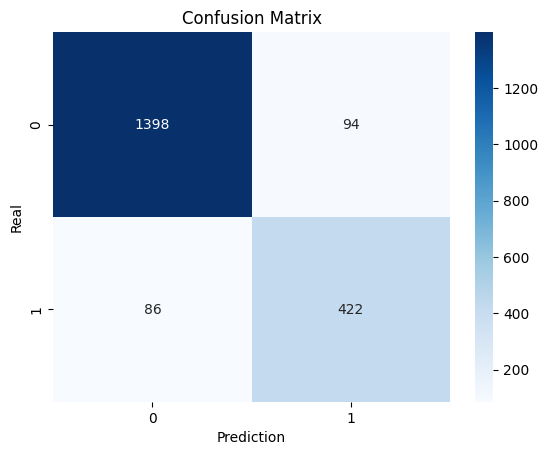

In [36]:
sns.heatmap(cf,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Real")
plt.show()

### Prediction with Decision Tree.

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
df.head()

,Experience_Years,Interview_Score,Degree,Hired
0,6.0,62.0,BCA,1
1,3.0,39.0,MBA,0
2,7.0,12.0,BTech,0
3,4.0,52.0,BTech,0
4,6.0,16.0,BTech,0


In [43]:
X = df_encoded[['Experience_Years', 'Interview_Score', 'Degree_BTech', 'Degree_MBA']]
y = df_encoded['Hired']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
mlmodel = DecisionTreeClassifier()

In [47]:
mlmodel.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [48]:
predic = mlmodel.predict(X_test)
predic

array([1, 0, 1, ..., 0, 0, 1], shape=(2000,))

In [50]:
sco = accuracy_score(y_test,predic)
print(sco * 100)

100.0


In [51]:
confusionmt = confusion_matrix(y_test,predic)
confusionmt

array([[1492,    0],
       [   0,  508]])

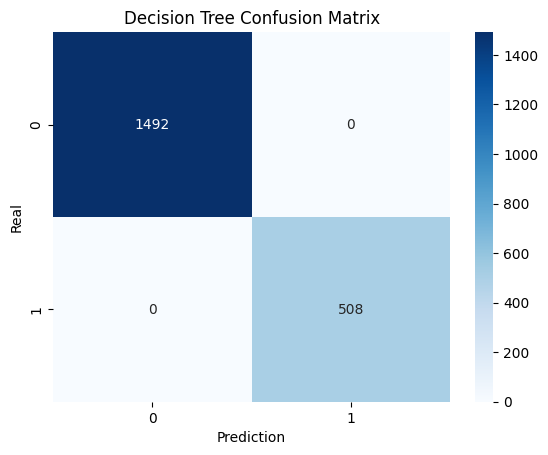

In [52]:
sns.heatmap(confusionmt,annot=True,fmt='d',cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Real")
plt.show()

In [ ]:
# Conclusion -- Here Decision tree is performing well in comparison of logistic regression because that works on mathematical 
              # formulas but decision tree work on if else condition so here due to clear pattern recognition it predicts
              # 100 percent accurate data.


### Prediction on same data with Random Forest.

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
X = df_encoded[['Experience_Years', 'Interview_Score', 'Degree_BTech', 'Degree_MBA']]
y = df_encoded['Hired']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
mo = RandomForestClassifier(n_estimators=10,max_depth=5,random_state=42)

In [76]:
mo.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

In [77]:
forecast = mo.predict(X_test)
forecast

array([1, 0, 1, ..., 0, 0, 1], shape=(2000,))

In [78]:
scr = accuracy_score(y_test,forecast)
print(scr * 100)

100.0


In [79]:
conf = confusion_matrix(y_test,forecast)
conf

array([[1492,    0],
       [   0,  508]])

In [80]:
rpt = classification_report(y_test,forecast)
print(rpt)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1492
           1       1.00      1.00      1.00       508

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



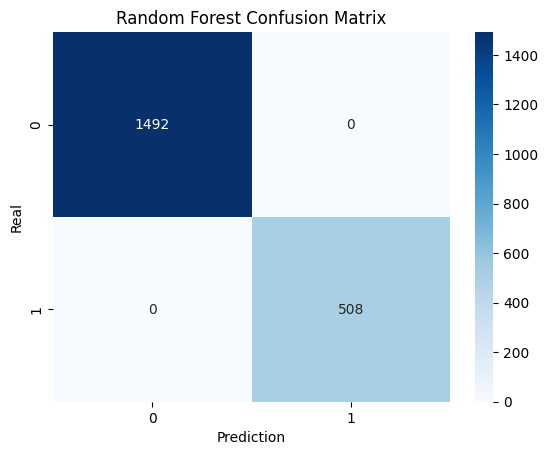

In [81]:
sns.heatmap(conf,annot=True,fmt='d',cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Real")
plt.show()

### Prediction on numbers with linear regression.

In [83]:
df_encoded.head()

,Experience_Years,Interview_Score,Hired,Degree_BTech,Degree_MBA
0,6.0,62.0,1,0,0
1,3.0,39.0,0,0,1
2,7.0,12.0,0,1,0
3,4.0,52.0,0,1,0
4,6.0,16.0,0,1,0


In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [94]:
from sklearn.metrics import r2_score, mean_squared_error

### Creating a copy of encoded data for changing paterns and parameter for linear regression data.

In [96]:
df_encoded_ne = df_encoded

In [100]:
df_encoded_ne.head()

,Experience_Years,Interview_Score,Hired,Degree_BTech,Degree_MBA,Expected_Salary
0,6.0,62.0,1,0,0,540000.0
1,3.0,39.0,0,0,1,420000.0
2,7.0,12.0,0,1,0,580000.0
3,4.0,52.0,0,1,0,460000.0
4,6.0,16.0,0,1,0,540000.0


### Making a pattern for linear regression data traning.

In [99]:
df_encoded_ne['Expected_Salary'] = (df_encoded_ne['Experience_Years'] * 40000) + 300000

In [101]:
X = df_encoded_ne[['Experience_Years','Degree_BTech','Degree_MBA']]
y = df_encoded_ne['Expected_Salary']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
scaler = MinMaxScaler()

In [103]:
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

In [89]:
mdl = LinearRegression()

In [104]:
mdl.fit(X_tr_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [105]:
prd = mdl.predict(X_te_scaled)
prd

array([500000., 340000., 540000., ..., 660000., 380000., 580000.],
      shape=(2000,))

In [106]:
rscore = r2_score(y_test,prd)
print(rscore * 100)

100.0


In [107]:
error = mean_squared_error(y_test,prd)
error

7.767986693338683e-19